## NAMA : Wandy Putra Purba
## NIM  : 4222311004

# Analisis Perbandingan Fungsi Aktivasi Sigmoid, Tanh, dan ReLU pada Model MLP untuk Klasifikasi Dataset Iris

## 1. Import Library

In [9]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

warnings.filterwarnings('ignore')
print("Import libraries berhasil.")

Import libraries berhasil.


## 2. Persiapan Dataset Iris

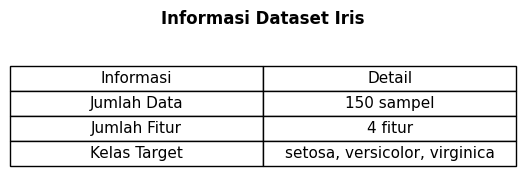

In [10]:
fig, ax = plt.subplots(figsize=(6, 2))
ax.axis('off')

data_info = [
    ['Jumlah Data',  f'{X.shape[0]} sampel'],
    ['Jumlah Fitur', f'{X.shape[1]} fitur'],
    ['Kelas Target', ', '.join(iris.target_names)]
]

tabel = ax.table(
    cellText  = data_info,
    colLabels = ['Informasi', 'Detail'],
    cellLoc   = 'center',
    loc       = 'center'
)

tabel.auto_set_font_size(False)
tabel.set_fontsize(11)
tabel.scale(1.5, 1.8)
plt.title('Informasi Dataset Iris', fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

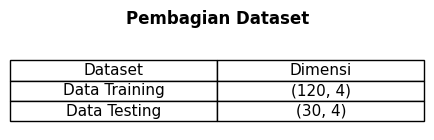

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

fig, ax = plt.subplots(figsize=(5, 1.5))
ax.axis('off')

data_split = [
    ['Data Training', str(X_train_scaled.shape)],
    ['Data Testing',  str(X_test_scaled.shape)]
]

tabel = ax.table(
    cellText  = data_split,
    colLabels = ['Dataset', 'Dimensi'],
    cellLoc   = 'center',
    loc       = 'center'
)

tabel.auto_set_font_size(False)
tabel.set_fontsize(11)
tabel.scale(1.5, 1.8)
plt.title('Pembagian Dataset', fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## 3. Arsitektur dan Parameter Model

Sebelum melatih model, saya menentukan dulu arsitektur dan parameter yang akan dipakai. Semua parameter dibuat sama untuk ketiga fungsi aktivasi agar hasil perbandingannya tidak condong ke salah satu.

| Parameter | Nilai |
|---|---|
| Hidden layers | 2 layer (64 neuron, 32 neuron) |
| Optimizer | Adam (Adaptive Moment Estimation) |
| Learning rate | 0.001 |
| Max iterasi | 2000 |
| Random state | 42 |
| Pembagian data | 80% train / 20% test |

Untuk jumlah hidden layer, saya pakai 2 layer dengan 64 dan 32 neuron. Menurut saya ukuran ini sudah cukup untuk dataset Iris yang tidak terlalu kompleks — kalau terlalu besar justru berpotensi overfit. Learning rate 0.001 saya pilih karena nilainya tidak terlalu besar dan tidak terlalu kecil, sehingga proses training lebih stabil. Random state 42 digunakan supaya setiap kali kode dijalankan ulang, hasilnya tetap sama dan bisa dibandingkan secara konsisten.

## 4. Pengujian Fungsi Aktivasi pada Model MLP

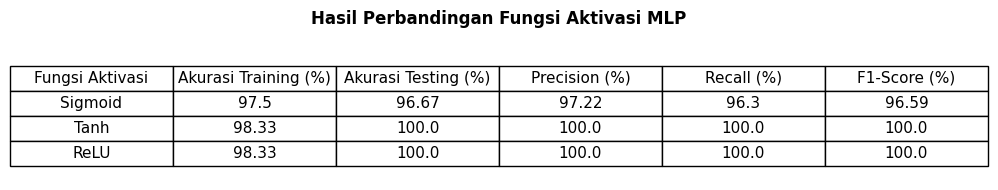

In [12]:
aktivasi_list = {
    'Sigmoid': 'logistic',
    'Tanh'   : 'tanh',
    'ReLU'   : 'relu'
}

hasil = []

for nama, kode in aktivasi_list.items():
    model = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation=kode,
        solver='adam',
        learning_rate_init=0.001,
        max_iter=2000,
        random_state=42
    )

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    acc_train  = accuracy_score(y_train, model.predict(X_train_scaled)) * 100
    acc_test   = accuracy_score(y_test,  y_pred) * 100
    precision  = precision_score(y_test, y_pred, average='macro') * 100
    recall     = recall_score(y_test,    y_pred, average='macro') * 100
    f1         = f1_score(y_test,        y_pred, average='macro') * 100

    hasil.append({
        'Fungsi Aktivasi'      : nama,
        'Akurasi Training (%)' : round(acc_train, 2),
        'Akurasi Testing (%)'  : round(acc_test,  2),
        'Precision (%)'        : round(precision,  2),
        'Recall (%)'           : round(recall,     2),
        'F1-Score (%)'         : round(f1,         2)
    })

fig, ax = plt.subplots(figsize=(10, 2))
ax.axis('off')

kolom = ['Fungsi Aktivasi', 'Akurasi Training (%)',
         'Akurasi Testing (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)']

baris = [[d['Fungsi Aktivasi'], d['Akurasi Training (%)'],
          d['Akurasi Testing (%)'], d['Precision (%)'],
          d['Recall (%)'],          d['F1-Score (%)']] for d in hasil]

tabel = ax.table(
    cellText  = baris,
    colLabels = kolom,
    cellLoc   = 'center',
    loc       = 'center'
)

tabel.auto_set_font_size(False)
tabel.set_fontsize(11)
tabel.scale(1.2, 1.8)
plt.title('Hasil Perbandingan Fungsi Aktivasi MLP', fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## 5. Perbandingan Kinerja Model Berdasarkan Fungsi Aktivasi

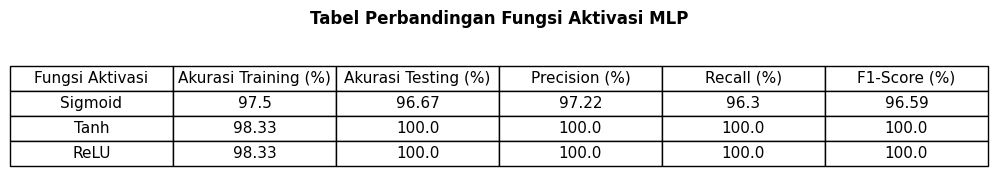

In [13]:
df_hasil = pd.DataFrame(hasil)
df_hasil = df_hasil.set_index('Fungsi Aktivasi')

fig, ax = plt.subplots(figsize=(10, 2))
ax.axis('off')

kolom = ['Fungsi Aktivasi'] + list(df_hasil.columns)
baris = [[idx] + list(row) for idx, row in zip(df_hasil.index, df_hasil.values)]

tabel = ax.table(
    cellText  = baris,
    colLabels = kolom,
    cellLoc   = 'center',
    loc       = 'center'
)

tabel.auto_set_font_size(False)
tabel.set_fontsize(11)
tabel.scale(1.2, 1.8)
plt.title('Tabel Perbandingan Fungsi Aktivasi MLP', fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## Kesimpulan


### Analisis Fungsi Aktivasi Terbaik

Setelah mencoba ketiga fungsi aktivasi, hasilnya cukup menarik. Tidak semua fungsi aktivasi memberikan hasil yang sama, meskipun parameter lainnya identik.

| Fungsi Aktivasi | Akurasi Testing | Keterangan |
|---|---|---|
| Sigmoid | 96.67% | Paling rendah di antara ketiganya |
| Tanh | 100% | Hasil sempurna, proses training cukup stabil |
| ReLU | 100% | Hasil sempurna, paling cepat dalam proses training |

Sigmoid ternyata sedikit tertinggal dibanding dua fungsi lainnya. Kemungkinan besar ini karena Sigmoid punya kelemahan di masalah vanishing gradient — gradiennya bisa mengecil terlalu cepat saat backpropagation, sehingga model jadi lebih lambat belajar dan hasilnya kurang optimal.

Tanh dan ReLU keduanya berhasil mencapai 100% di semua metrik. Tapi kalau saya perhatikan dari sisi proses training-nya, ReLU terasa lebih responsif — ini memang sudah dikenal sebagai salah satu kelebihan ReLU dibanding fungsi aktivasi lain.

Jadi pilihan saya jatuh ke **ReLU** sebagai fungsi aktivasi terbaik untuk kasus ini. Hasilnya sama dengan Tanh, tapi prosesnya lebih efisien dan penerapannya lebih luas di dunia nyata.

Satu hal yang perlu saya catat — hasil 100% ini tidak perlu terlalu dilebih-lebihkan. Dataset Iris memang tergolong mudah karena hanya punya 150 data dan perbedaan antar kelasnya sudah cukup jelas. Di dataset yang lebih besar dan kompleks, hasilnya tentu akan berbeda.